<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 15.15 — Linear Regression with the Diabetes Dataset

## 1. Imports and reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

pd.set_option('display.precision', 4)
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 11


## 2. Load the diabetes dataset

The dataset contains **442 samples** and **10 numeric baseline features**:

- `age`: age
- `sex`: sex
- `bmi`: body mass index
- `bp`: average blood pressure
- `s1`: total serum cholesterol
- `s2`: low-density lipoproteins
- `s3`: high-density lipoproteins
- `s4`: total cholesterol / HDL
- `s5`: possibly the log of serum triglycerides
- `s6`: blood sugar

By default, Scikit-Learn provides mean-centered and scaled feature values. The target is a quantitative measure of disease progression one year after baseline.


In [2]:
diabetes = load_diabetes()
print(diabetes.DESCR)


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Confirm the dimensions and feature names

`data` should have one row per patient and one column per feature. `target` should contain one response value for every patient.


In [3]:
print('Feature matrix shape:', diabetes.data.shape)
print('Target array shape:  ', diabetes.target.shape)
print('Feature names:       ', diabetes.feature_names)


Feature matrix shape: (442, 10)
Target array shape:   (442,)
Feature names:        ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 3. Explore the data with pandas

Create a `DataFrame` from the feature matrix and add the target as a column named `DiseaseProgression`.


In [4]:
diabetes_df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)
diabetes_df['DiseaseProgression'] = diabetes.target
diabetes_df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


### Check data types and missing values

Linear regression requires numeric inputs and cannot directly train on missing values. The following checks confirm that the columns are numeric and that this dataset has no missing entries.


In [5]:
print(diabetes_df.dtypes)
print('\nTotal missing values:', diabetes_df.isna().sum().sum())


age                   float64
sex                   float64
bmi                   float64
bp                    float64
s1                    float64
s2                    float64
s3                    float64
s4                    float64
s5                    float64
s6                    float64
DiseaseProgression    float64
dtype: object

Total missing values: 0


### Summary statistics

`describe()` displays the count, mean, standard deviation, minimum, quartiles, and maximum for each column.


In [6]:
diabetes_df.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
count,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,442.0000
mean,-2.5118e-19,1.2308e-17,-2.2456e-16,-4.7976e-17,-1.3815e-17,3.9184e-17,-5.7772e-18,-9.0425e-18,9.2937e-17,1.1303e-17,152.1335
std,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,77.0930
min,-1.0723e-01,-4.4642e-02,-9.0275e-02,-1.1240e-01,-1.2678e-01,-1.1561e-01,-1.0231e-01,-7.6395e-02,-1.2610e-01,-1.3777e-01,25.0000
25%,-3.7299e-02,-4.4642e-02,-3.4229e-02,-3.6656e-02,-3.4248e-02,-3.0358e-02,-3.5117e-02,-3.9493e-02,-3.3246e-02,-3.3179e-02,87.0000
50%,5.3831e-03,-4.4642e-02,-7.2838e-03,-5.6704e-03,-4.3209e-03,-3.8191e-03,-6.5845e-03,-2.5923e-03,-1.9472e-03,-1.0777e-03,140.5000
75%,3.8076e-02,5.0680e-02,3.1248e-02,3.5644e-02,2.8358e-02,2.9844e-02,2.9312e-02,3.4309e-02,3.2432e-02,2.7917e-02,211.5000
max,1.1073e-01,5.0680e-02,1.7056e-01,1.3204e-01,1.5391e-01,1.9879e-01,1.8118e-01,1.8523e-01,1.3360e-01,1.3561e-01,346.0000


### Correlation with the target

Correlation measures the direction and strength of a linear relationship. Values near `1` indicate a strong positive relationship, values near `-1` indicate a strong negative relationship, and values near `0` indicate a weak linear relationship. Correlation does not prove causation.


In [7]:
target_correlations = (
    diabetes_df.corr(numeric_only=True)['DiseaseProgression']
    .drop('DiseaseProgression')
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
target_correlations.to_frame(name='Correlation with target')


,Correlation with target
bmi,0.5865
s5,0.5659
bp,0.4415
s4,0.4305
s3,-0.3948
s6,0.3825
s1,0.2120
age,0.1879
s2,0.1741
sex,0.0431


**Initial analysis:** `bmi` and `s5` have the strongest positive linear correlations with disease progression. `bp` is also positively related, while `s3` has the strongest negative correlation. These are individual correlations; the fitted multiple regression coefficients can differ because the model considers all features simultaneously.


## 4. Visualize the data

Following Section 15.5, use `DataFrame.sample` to select a reproducible 10% subset for graphing. Each scatterplot compares one baseline feature with the target. The full dataset remains in use for training, testing, correlations, and model selection.


Visualization sample shape: (44, 11)


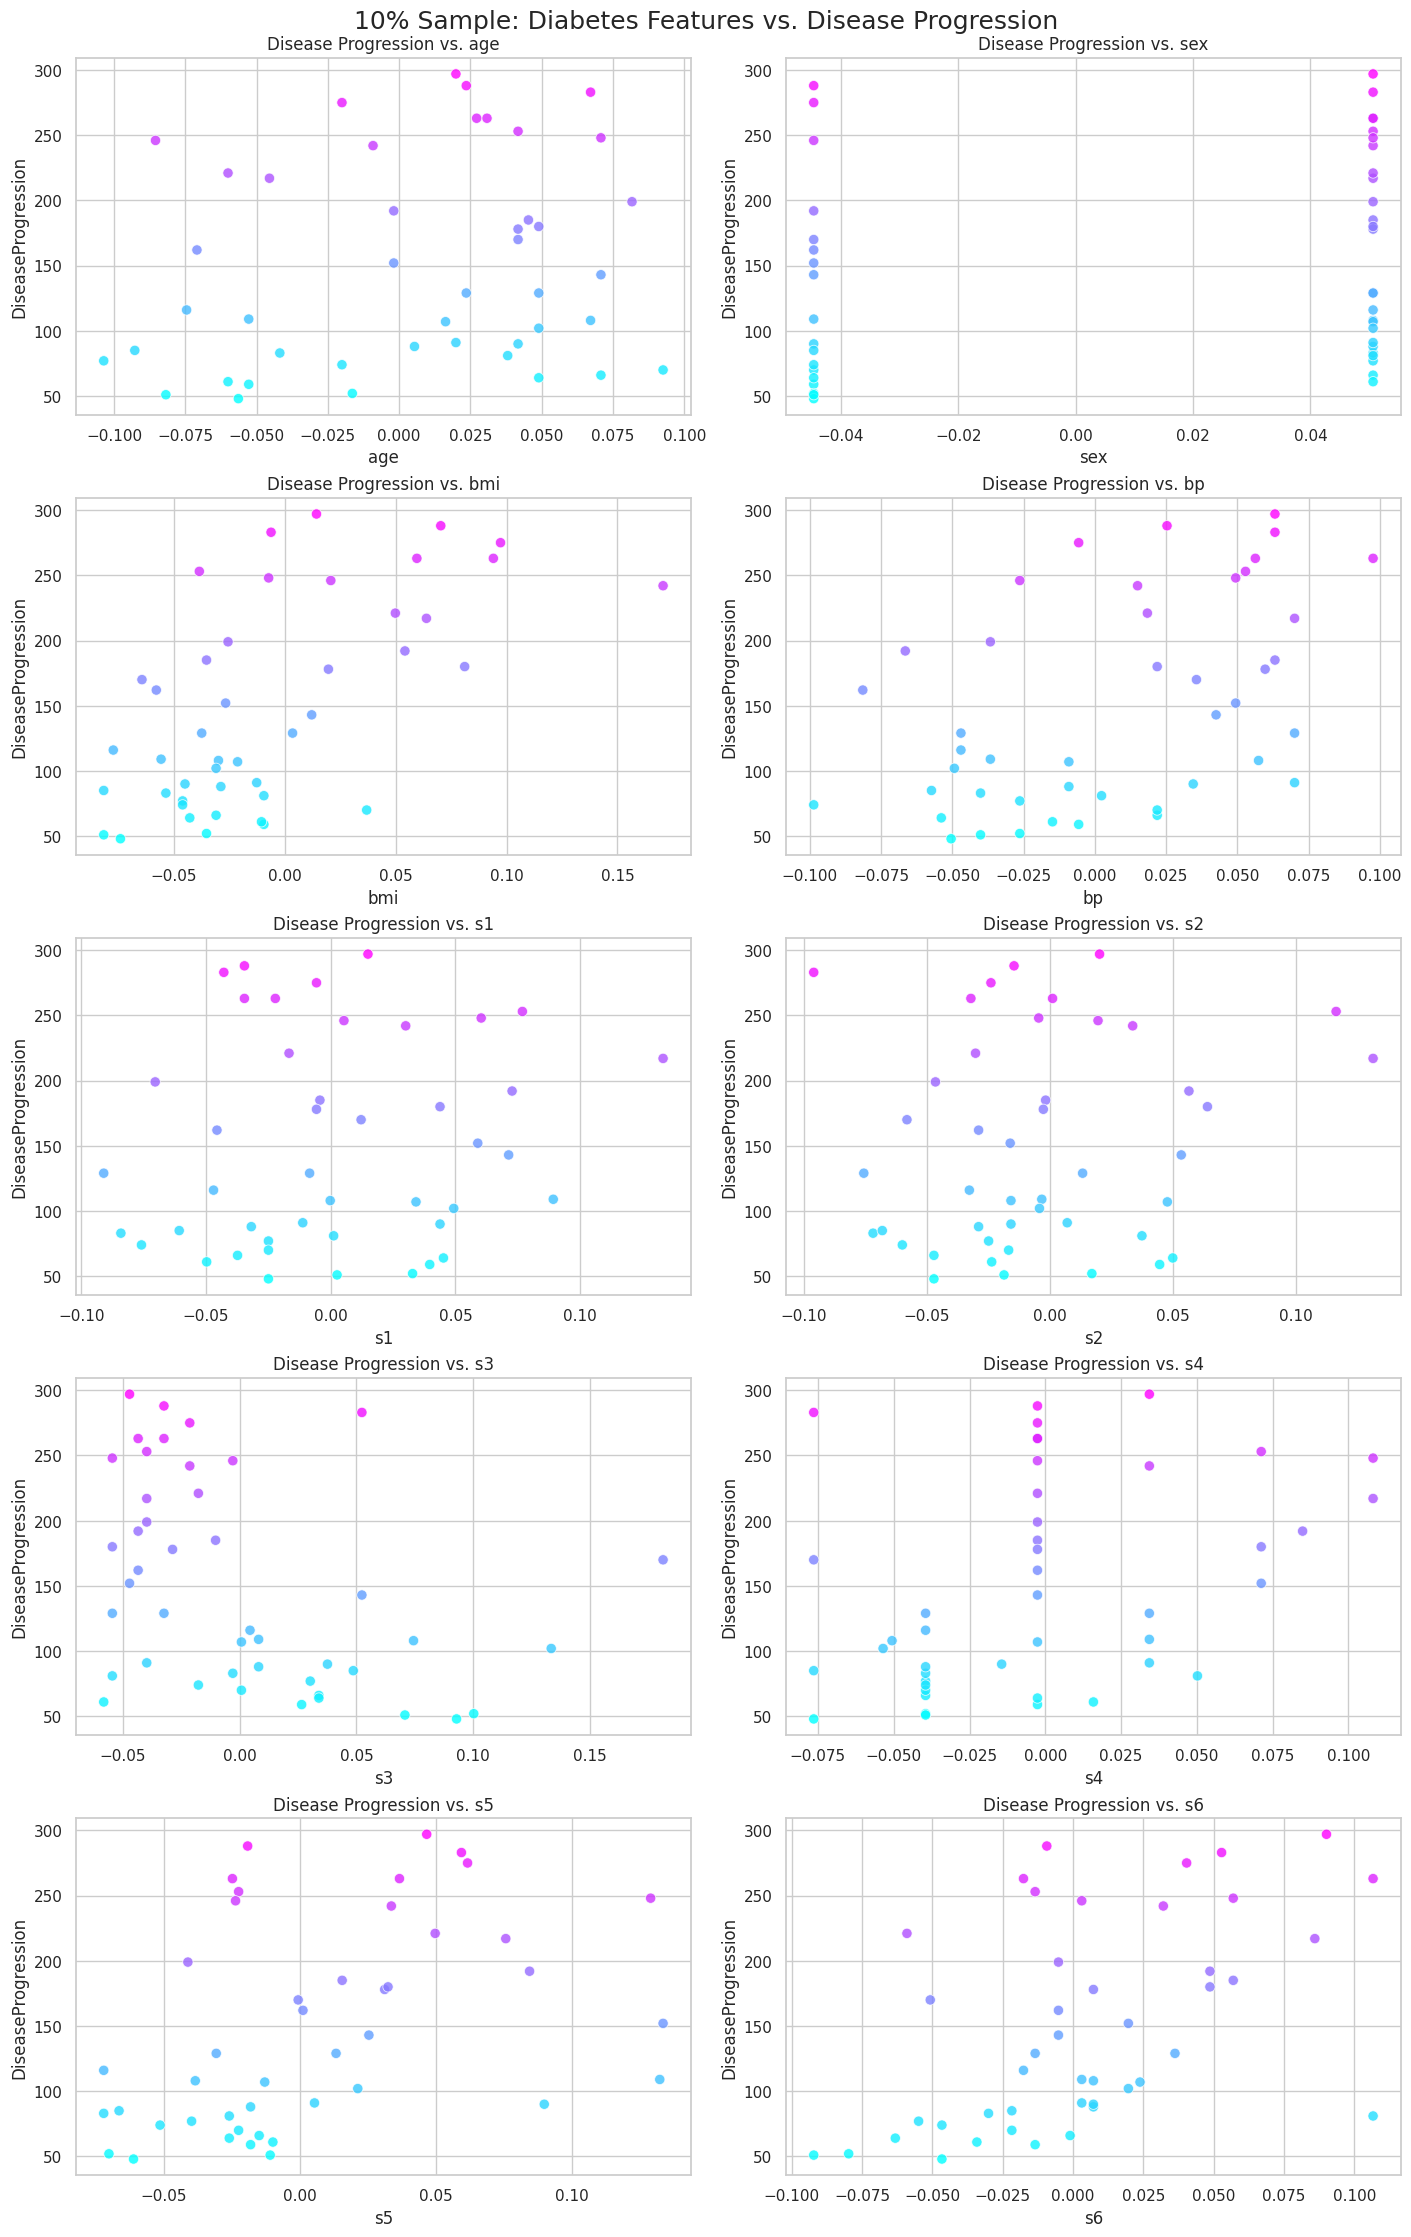

In [8]:
sample_df = diabetes_df.sample(frac=0.1, random_state=17)
print('Visualization sample shape:', sample_df.shape)

fig, axes = plt.subplots(5, 2, figsize=(14, 22), constrained_layout=True)

for feature, axis in zip(diabetes.feature_names, axes.flat):
    sns.scatterplot(
        data=sample_df,
        x=feature,
        y='DiseaseProgression',
        hue='DiseaseProgression',
        palette='cool',
        legend=False,
        ax=axis,
        alpha=0.80,
        s=55
    )
    axis.set_title(f'Disease Progression vs. {feature}')

fig.suptitle('10% Sample: Diabetes Features vs. Disease Progression', fontsize=18, y=1.01)
plt.show()


### Correlation heatmap

The heatmap shows relationships among all features and the target. It also reveals correlations among predictors, which helps explain why coefficient magnitudes should be interpreted cautiously when predictors overlap in the information they contain.


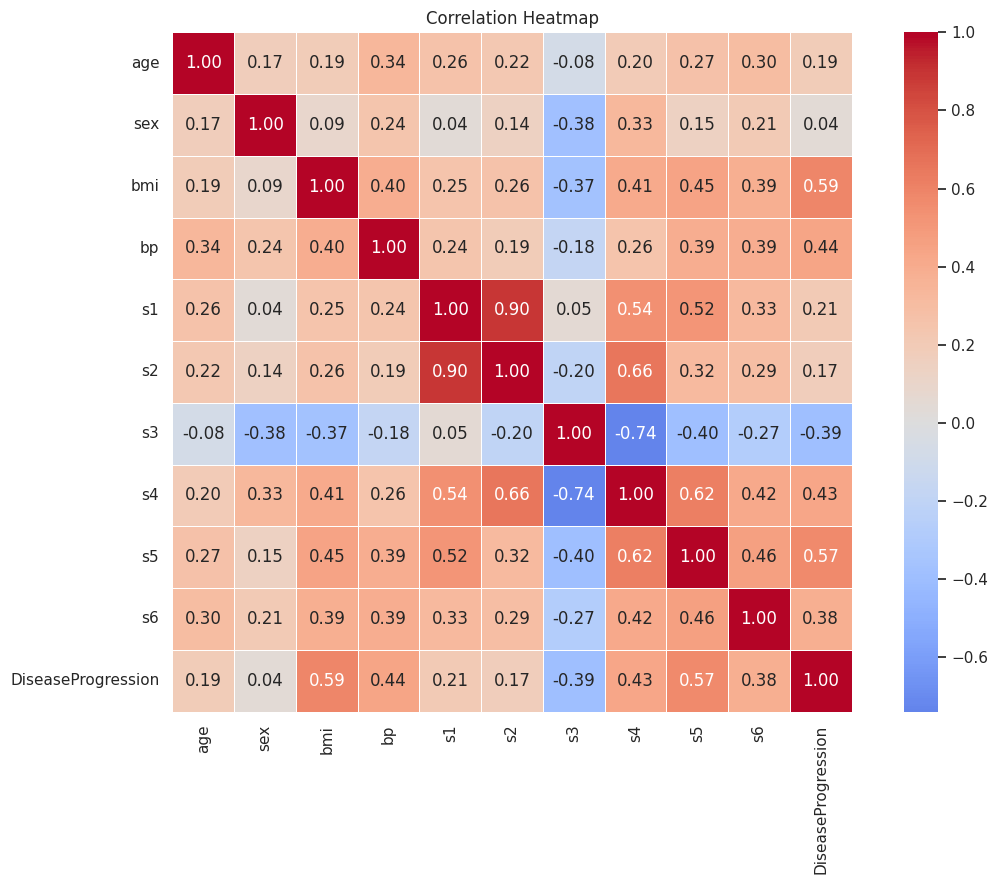

In [9]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    diabetes_df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 5. Split the data into training and testing sets

The default `test_size` for `train_test_split` is 25%, so 331 observations are used for training and 111 are held out for testing. The model never sees the test targets during training.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data,
    diabetes.target,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)


X_train shape: (331, 10)
X_test shape:  (111, 10)
y_train shape: (331,)
y_test shape:  (111,)


## 6. Train the multiple linear regression model

`LinearRegression` fits the equation

\[
\hat{y}=b_0+b_1x_1+b_2x_2+\cdots+b_{10}x_{10}
\]

where the coefficients describe the fitted change in the predicted target for a one-unit change in a feature while the other features are held constant.


In [11]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

print('Model training complete.')


Model training complete.


### Inspect the intercept and coefficients

The features are already scaled by `load_diabetes`, which makes coefficient magnitudes more comparable than they would be if the features used unrelated units. However, correlated predictors can still make individual coefficients unstable, so coefficient size alone should not be treated as causal importance.


In [12]:
coefficient_table = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': linear_regression.coef_,
    'Absolute coefficient': np.abs(linear_regression.coef_)
}).sort_values('Absolute coefficient', ascending=False)

print(f'Intercept: {linear_regression.intercept_:.4f}')
coefficient_table


Intercept: 152.2282


,Feature,Coefficient,Absolute coefficient
8,s5,622.3287,622.3287
2,bmi,523.0634,523.0634
4,s1,-336.1615,336.1615
3,bp,310.5135,310.5135
1,sex,-266.4571,266.4571
5,s2,137.3393,137.3393
6,s3,-131.1392,131.1392
9,s6,60.4665,60.4665
0,age,-60.2198,60.2198
7,s4,-1.1492,1.1492


**Coefficient analysis:** In this fitted model, `s5` and `bmi` have the largest positive coefficients. `s1` and `sex` have large negative coefficients. The signs and magnitudes reflect the joint model, not isolated cause-and-effect relationships.


## 7. Test the model

Use the fitted model to predict the held-out test targets, then compare the first ten expected and predicted values.


In [13]:
predicted = linear_regression.predict(X_test)
expected = y_test

comparison_df = pd.DataFrame({
    'Expected': expected,
    'Predicted': predicted,
    'Residual': expected - predicted
})
comparison_df.head(10)


,Expected,Predicted,Residual
0,79.0,115.4647,-36.4647
1,55.0,83.4585,-28.4585
2,109.0,160.7773,-51.7773
3,178.0,187.6571,-9.6571
4,39.0,72.7212,-33.7212
5,321.0,230.5601,90.4399
6,158.0,94.9288,63.0712
7,132.0,256.4074,-124.4074
8,52.0,177.6625,-125.6625
9,201.0,100.3318,100.6682


## 8. Visualize expected versus predicted values

The dashed line represents perfect predictions. Points near the line are more accurate; vertical distance from the line represents prediction error.


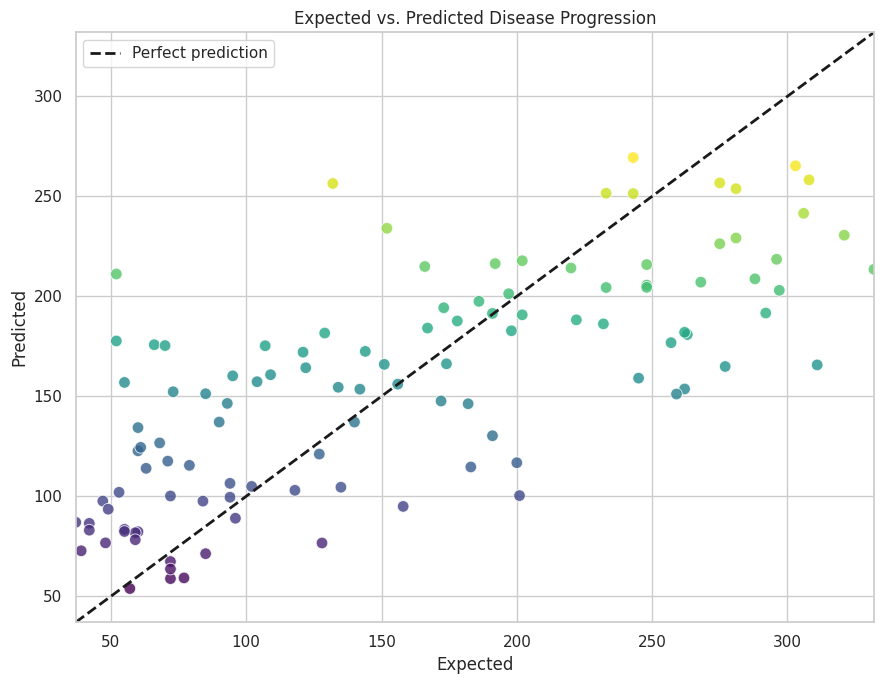

In [14]:
figure, axis = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=comparison_df,
    x='Expected',
    y='Predicted',
    hue='Predicted',
    palette='viridis',
    legend=False,
    s=70,
    alpha=0.80,
    ax=axis
)

start = min(expected.min(), predicted.min())
end = max(expected.max(), predicted.max())
axis.plot([start, end], [start, end], 'k--', linewidth=2, label='Perfect prediction')
axis.set_xlim(start, end)
axis.set_ylim(start, end)
axis.set_title('Expected vs. Predicted Disease Progression')
axis.legend()
plt.tight_layout()
plt.show()


## 9. Evaluate regression metrics

- **MAE:** average absolute prediction error.
- **MSE:** average squared prediction error; larger errors receive more weight.
- **RMSE:** square root of MSE, expressed in the same units as the target.
- **R²:** proportion of target variance explained by the model on the test set. Higher is better; `1.0` is perfect, `0.0` is no better than predicting the test-set mean, and negative values are possible for poor models.


In [15]:
mae = mean_absolute_error(expected, predicted)
mse = mean_squared_error(expected, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(expected, predicted)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae, mse, rmse, r2]
})
metrics_table


,Metric,Value
0,MAE,47.1713
1,MSE,3458.2307
2,RMSE,58.8067
3,R-squared,0.5322


In [16]:
print(f'Mean Absolute Error:  {mae:.2f}')
print(f'Mean Squared Error:   {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.3f}')


Mean Absolute Error:  47.17
Mean Squared Error:   3458.23
Root Mean Squared Error: 58.81
R-squared: 0.532


**Test-set interpretation:** The model obtains an R² of approximately **0.532**, so it explains about **53.2%** of the variation in the held-out target values. Its MAE is approximately **47.17** target units and its RMSE is approximately **58.81** target units. The model captures a meaningful linear signal, but the remaining errors show that these ten baseline variables and a purely linear relationship do not explain all variation in disease progression.


## 10. Compare linear models with 10-fold cross-validation

A single train-test split depends on which observations happen to be held out. Ten-fold cross-validation gives a more reliable model comparison by training and evaluating each estimator across ten different folds. The same shuffled folds are used for every model.

The comparison follows the Section 15.5 case study and evaluates the default settings for `LinearRegression`, `ElasticNet`, `Lasso`, and `Ridge` using R².


In [17]:
estimators = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
model_results = []

for estimator_name, estimator in estimators.items():
    scores = cross_val_score(
        estimator,
        diabetes.data,
        diabetes.target,
        cv=kfold,
        scoring='r2'
    )
    model_results.append({
        'Model': estimator_name,
        'Mean R-squared': scores.mean(),
        'Standard deviation': scores.std()
    })

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values('Mean R-squared', ascending=False)
    .reset_index(drop=True)
)
model_results_df


,Model,Mean R-squared,Standard deviation
0,LinearRegression,0.4747,0.0797
1,Ridge,0.4213,0.0744
2,Lasso,0.3385,0.0537
3,ElasticNet,-0.0021,0.0131


In [18]:
best_model = model_results_df.iloc[0]
print(
    f"Best model with default settings: {best_model['Model']} "
    f"(mean cross-validated R-squared = {best_model['Mean R-squared']:.3f})"
)


Best model with default settings: LinearRegression (mean cross-validated R-squared = 0.475)
